In [1]:
!pip install earthaccess nasa-pace-data-reader cartopy h5py --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import warnings
warnings.filterwarnings("ignore")
from nasa_pace_data_reader import L1, plot as pace_plot
from scipy.stats import spearmanr

In [ ]:
HARP2_FILE    = "PACE/PACE_HARP2.20240926T203011.L1C.V3.5km.nc"
AIRHARP2_FILE = "ER2/PACEPAX-AH2MAP-L1C_ER2_20240926T202945_R0.nc"

In [4]:
l1c = L1.L1C()
harp2_dict = l1c.read(HARP2_FILE)
print("HARP2 keys:", list(harp2_dict.keys()))

Reading HARP2 data from PACE/2024-9-26/PACE_HARP2.20240926T203011.L1C.V3.5km.nc
HARP2 keys: ['date_time', 'latitude', 'longitude', 'scattering_angle', 'solar_zenith_angle', 'solar_azimuth_angle', 'sensor_zenith_angle', 'sensor_azimuth_angle', 'height', 'rotation_angle', '_units', 'i', 'q', 'u', 'dolp', 'F0', 'view_angles', 'intensity_wavelength']


In [5]:
ds = xr.open_dataset(AIRHARP2_FILE, group="geolocation_data", mask_and_scale=True)
ah2_lat  = ds["latitude"].values
ah2_lon  = ds["longitude"].values
ah2_sza  = ds["solar_zenith_angle"].values
ah2_scat = ds["scattering_angle"].values

ds_obs = xr.open_dataset(AIRHARP2_FILE, group="observation_data", mask_and_scale=True)
ah2_i    = ds_obs["i"].values
ah2_q    = ds_obs["q"].values
ah2_u    = ds_obs["u"].values
ah2_dolp = ds_obs["dolp"].values

ds_bands = xr.open_dataset(AIRHARP2_FILE, group="sensor_views_bands", mask_and_scale=True)
ah2_view_angles = ds_bands["sensor_view_angle"].values.flatten()
ah2_wavelengths = ds_bands["polarization_wavelength"].values.flatten()
ah2_f0          = ds_bands["intensity_f0"].values.flatten()

print(f"AirHARP2 i shape: {ah2_i.shape}")

AirHARP2 i shape: (251, 239, 90, 1)


In [6]:
bands = {
    '440nm (blue)':  np.where(np.abs(ah2_wavelengths - 440) < 10)[0],
    '549nm (green)': np.where(np.abs(ah2_wavelengths - 549) < 10)[0],
    '664nm (red)':   np.where(np.abs(ah2_wavelengths - 664) < 10)[0],
    '864nm (nir)':   np.where(np.abs(ah2_wavelengths - 864) < 10)[0],
}
colors = {
    '440nm (blue)':  'blue',
    '549nm (green)': 'green',
    '664nm (red)':   'red',
    '864nm (nir)':   'darkred',
}
ah2_band_order = ['440nm (blue)', '549nm (green)', '664nm (red)', '864nm (nir)']
h2_band_order  = ['Blue', 'Green', 'Red', 'NIR']

In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

h2_pixel = [24, 258]
h2_target_lat = harp2_dict['latitude'][h2_pixel[0], h2_pixel[1]]
h2_target_lon = harp2_dict['longitude'][h2_pixel[0], h2_pixel[1]]

dist_sq = (ah2_lat - h2_target_lat)**2 + (ah2_lon - h2_target_lon)**2
ah2_pixel = list(np.unravel_index(np.nanargmin(dist_sq), ah2_lat.shape))

sep_km = haversine_km(h2_target_lat, h2_target_lon,
                       ah2_lat[ah2_pixel[0], ah2_pixel[1]], ah2_lon[ah2_pixel[0], ah2_pixel[1]])
print(f"HARP2 pixel {h2_pixel} <-> AirHARP2 pixel {ah2_pixel}, separation: {sep_km:.3f} km")

HARP2 pixel [24, 258] <-> AirHARP2 pixel [9, 123], separation: 0.118 km


In [ ]:
sza_val = ah2_sza[ah2_pixel[0], ah2_pixel[1], 0]

# Raw radiance 
ah2_i_pix = ah2_i[ah2_pixel[0], ah2_pixel[1], :, 0]
ah2_q_pix = ah2_q[ah2_pixel[0], ah2_pixel[1], :, 0]
ah2_u_pix = ah2_u[ah2_pixel[0], ah2_pixel[1], :, 0]
ah2_dp    = ah2_dolp[ah2_pixel[0], ah2_pixel[1], :, 0]
ah2_scat_pixel = ah2_scat[ah2_pixel[0], ah2_pixel[1], :]

# Reflectance 
ah2_ri = np.pi * ah2_i_pix / (ah2_f0 * np.cos(np.radians(sza_val)))
ah2_rq = np.pi * ah2_q_pix / (ah2_f0 * np.cos(np.radians(sza_val)))
ah2_ru = np.pi * ah2_u_pix / (ah2_f0 * np.cos(np.radians(sza_val)))

In [9]:
harp2_band_names = ['Blue', 'Green', 'Red', 'NIR']
harp2_band_data  = {}

plt_ = pace_plot.Plot(harp2_dict)
h2_sza_pix = np.squeeze(np.asarray(harp2_dict['solar_zenith_angle'])[h2_pixel[0], h2_pixel[1]])

for band in harp2_band_names:
    plt_.setBand(band)
    idx = plt_.bandAngles

    i_raw = np.array(harp2_dict['i'][h2_pixel[0], h2_pixel[1], idx]).squeeze()
    q_raw = np.array(harp2_dict['q'][h2_pixel[0], h2_pixel[1], idx]).squeeze()
    u_raw = np.array(harp2_dict['u'][h2_pixel[0], h2_pixel[1], idx]).squeeze()
    dolp  = np.array(harp2_dict['dolp'][h2_pixel[0], h2_pixel[1], idx]).squeeze()

    f0_band  = np.asarray(harp2_dict['F0'])[idx].squeeze()
    sza_band = h2_sza_pix if np.ndim(h2_sza_pix) == 0 else np.asarray(h2_sza_pix)[idx].squeeze()

    harp2_band_data[band] = {
        'view_angles':      harp2_dict['view_angles'][idx],
        'scattering_angle': harp2_dict['scattering_angle'][h2_pixel[0], h2_pixel[1], idx],
        'i': i_raw, 'q': q_raw, 'u': u_raw, 'dolp': dolp,
        'ri': np.pi * i_raw / (f0_band * np.cos(np.radians(sza_band))),
        'rq': np.pi * q_raw / (f0_band * np.cos(np.radians(sza_band))),
        'ru': np.pi * u_raw / (f0_band * np.cos(np.radians(sza_band))),
    }

Instrument set to HARP2
...Band set to blue
...Band set to green
...Band set to red
...Band set to nir


In [ ]:
# Creating superpixel
r, c = ah2_pixel
row_spacing_km = haversine_km(ah2_lat[r, c], ah2_lon[r, c], ah2_lat[r+1, c], ah2_lon[r+1, c])
col_spacing_km = haversine_km(ah2_lat[r, c], ah2_lon[r, c], ah2_lat[r, c+1], ah2_lon[r, c+1])

HARP2_RESOLUTION_KM = 5.0
n_rows = max(1, round(HARP2_RESOLUTION_KM / row_spacing_km))
n_cols = max(1, round(HARP2_RESOLUTION_KM / col_spacing_km))

print(f"AirHARP2 pixel spacing: {row_spacing_km:.3f} km (row), {col_spacing_km:.3f} km (col)")
print(f"Superpixel window: {n_rows} rows x {n_cols} cols of AirHARP2 pixels")

half_r, half_c = n_rows // 2, n_cols // 2
r0, r1 = max(0, r - half_r), min(ah2_lat.shape[0], r + half_r + 1)
c0, c1 = max(0, c - half_c), min(ah2_lat.shape[1], c + half_c + 1)
print(f"Superpixel window: rows [{r0}:{r1}], cols [{c0}:{c1}]  ({(r1-r0)*(c1-c0)} pixels averaged)")

#Averaging
ah2_i_super    = np.nanmean(ah2_i[r0:r1, c0:c1, :, 0], axis=(0, 1))
ah2_q_super    = np.nanmean(ah2_q[r0:r1, c0:c1, :, 0], axis=(0, 1))
ah2_u_super    = np.nanmean(ah2_u[r0:r1, c0:c1, :, 0], axis=(0, 1))
ah2_dp_super   = np.nanmean(ah2_dolp[r0:r1, c0:c1, :, 0], axis=(0, 1))
ah2_scat_super = np.nanmean(ah2_scat[r0:r1, c0:c1, :], axis=(0, 1))
ah2_sza_super  = np.nanmean(ah2_sza[r0:r1, c0:c1, 0])

ah2_ri_super = np.pi * ah2_i_super / (ah2_f0 * np.cos(np.radians(ah2_sza_super)))
ah2_rq_super = np.pi * ah2_q_super / (ah2_f0 * np.cos(np.radians(ah2_sza_super)))
ah2_ru_super = np.pi * ah2_u_super / (ah2_f0 * np.cos(np.radians(ah2_sza_super)))

print(f"Superpixel R_i range: {np.nanmin(ah2_ri_super):.3f} to {np.nanmax(ah2_ri_super):.3f}")

AirHARP2 pixel spacing: 0.252 km (row), 0.250 km (col)
Superpixel window: 20 rows x 20 cols of AirHARP2 pixels


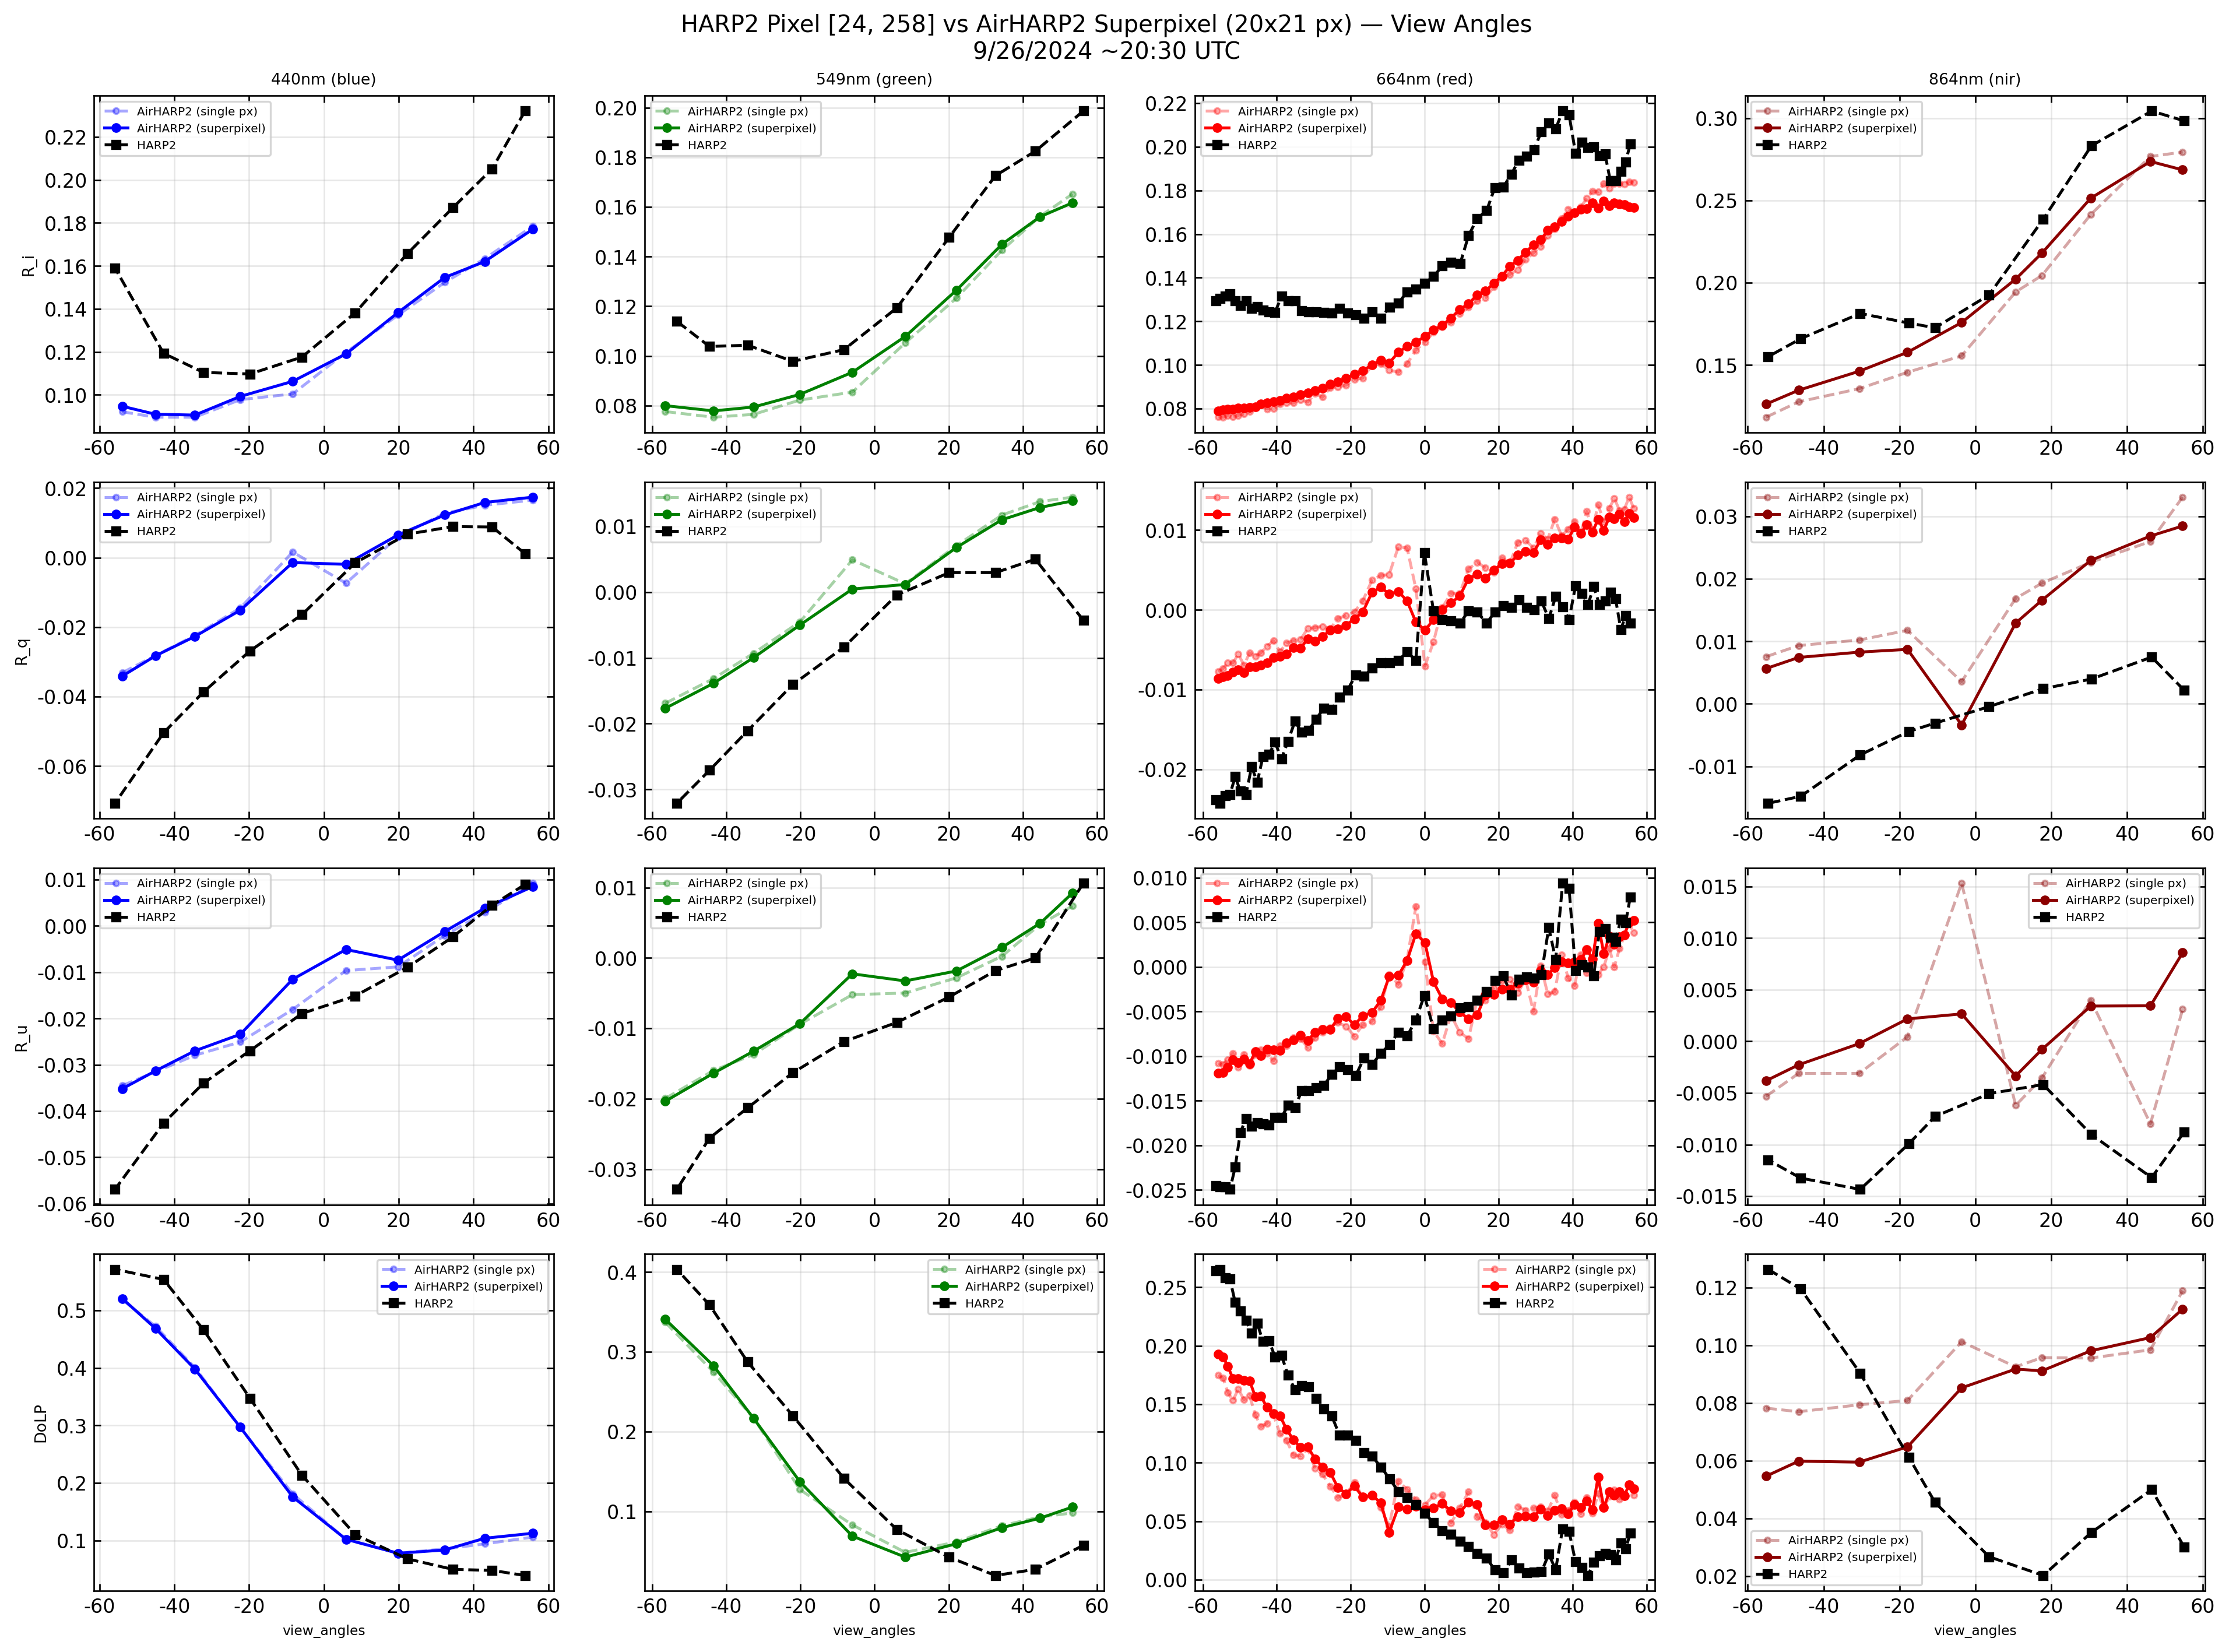

In [ ]:
ah2_vars_single = {'R_i': ah2_ri, 'R_q': ah2_rq, 'R_u': ah2_ru, 'DoLP': ah2_dp}
ah2_vars_super  = {'R_i': ah2_ri_super, 'R_q': ah2_rq_super, 'R_u': ah2_ru_super, 'DoLP': ah2_dp_super}
h2_var_keys     = ['ri', 'rq', 'ru', 'dolp']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))

for row, (var_label, h2_key) in enumerate(zip(ah2_vars_single.keys(), h2_var_keys)):
    for col, (ah2_band, h2_band) in enumerate(zip(ah2_band_order, h2_band_order)):
        ax, idx = axes[row, col], bands[ah2_band]
        ax.plot(ah2_view_angles[idx], ah2_vars_single[var_label][idx], 'o--', color=colors[ah2_band], alpha=0.35, markersize=3, label='AirHARP2 (single px)')
        ax.plot(ah2_view_angles[idx], ah2_vars_super[var_label][idx], 'o-', color=colors[ah2_band], markersize=4, label='AirHARP2 (superpixel)')
        ax.plot(harp2_band_data[h2_band]['view_angles'], harp2_band_data[h2_band][h2_key], 's--', color='black', markersize=4, label='HARP2')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=6)
        if row == 0: ax.set_title(ah2_band, fontsize=8)
        if col == 0: ax.set_ylabel(var_label, fontsize=8)
        if row == 3: ax.set_xlabel('view_angles', fontsize=7)
fig.suptitle(f"HARP2 Pixel {h2_pixel} vs AirHARP2 Superpixel ({r1-r0}x{c1-c0} px) — View Angles\n9/26/2024 ~20:30 UTC")
plt.tight_layout()
plt.show()

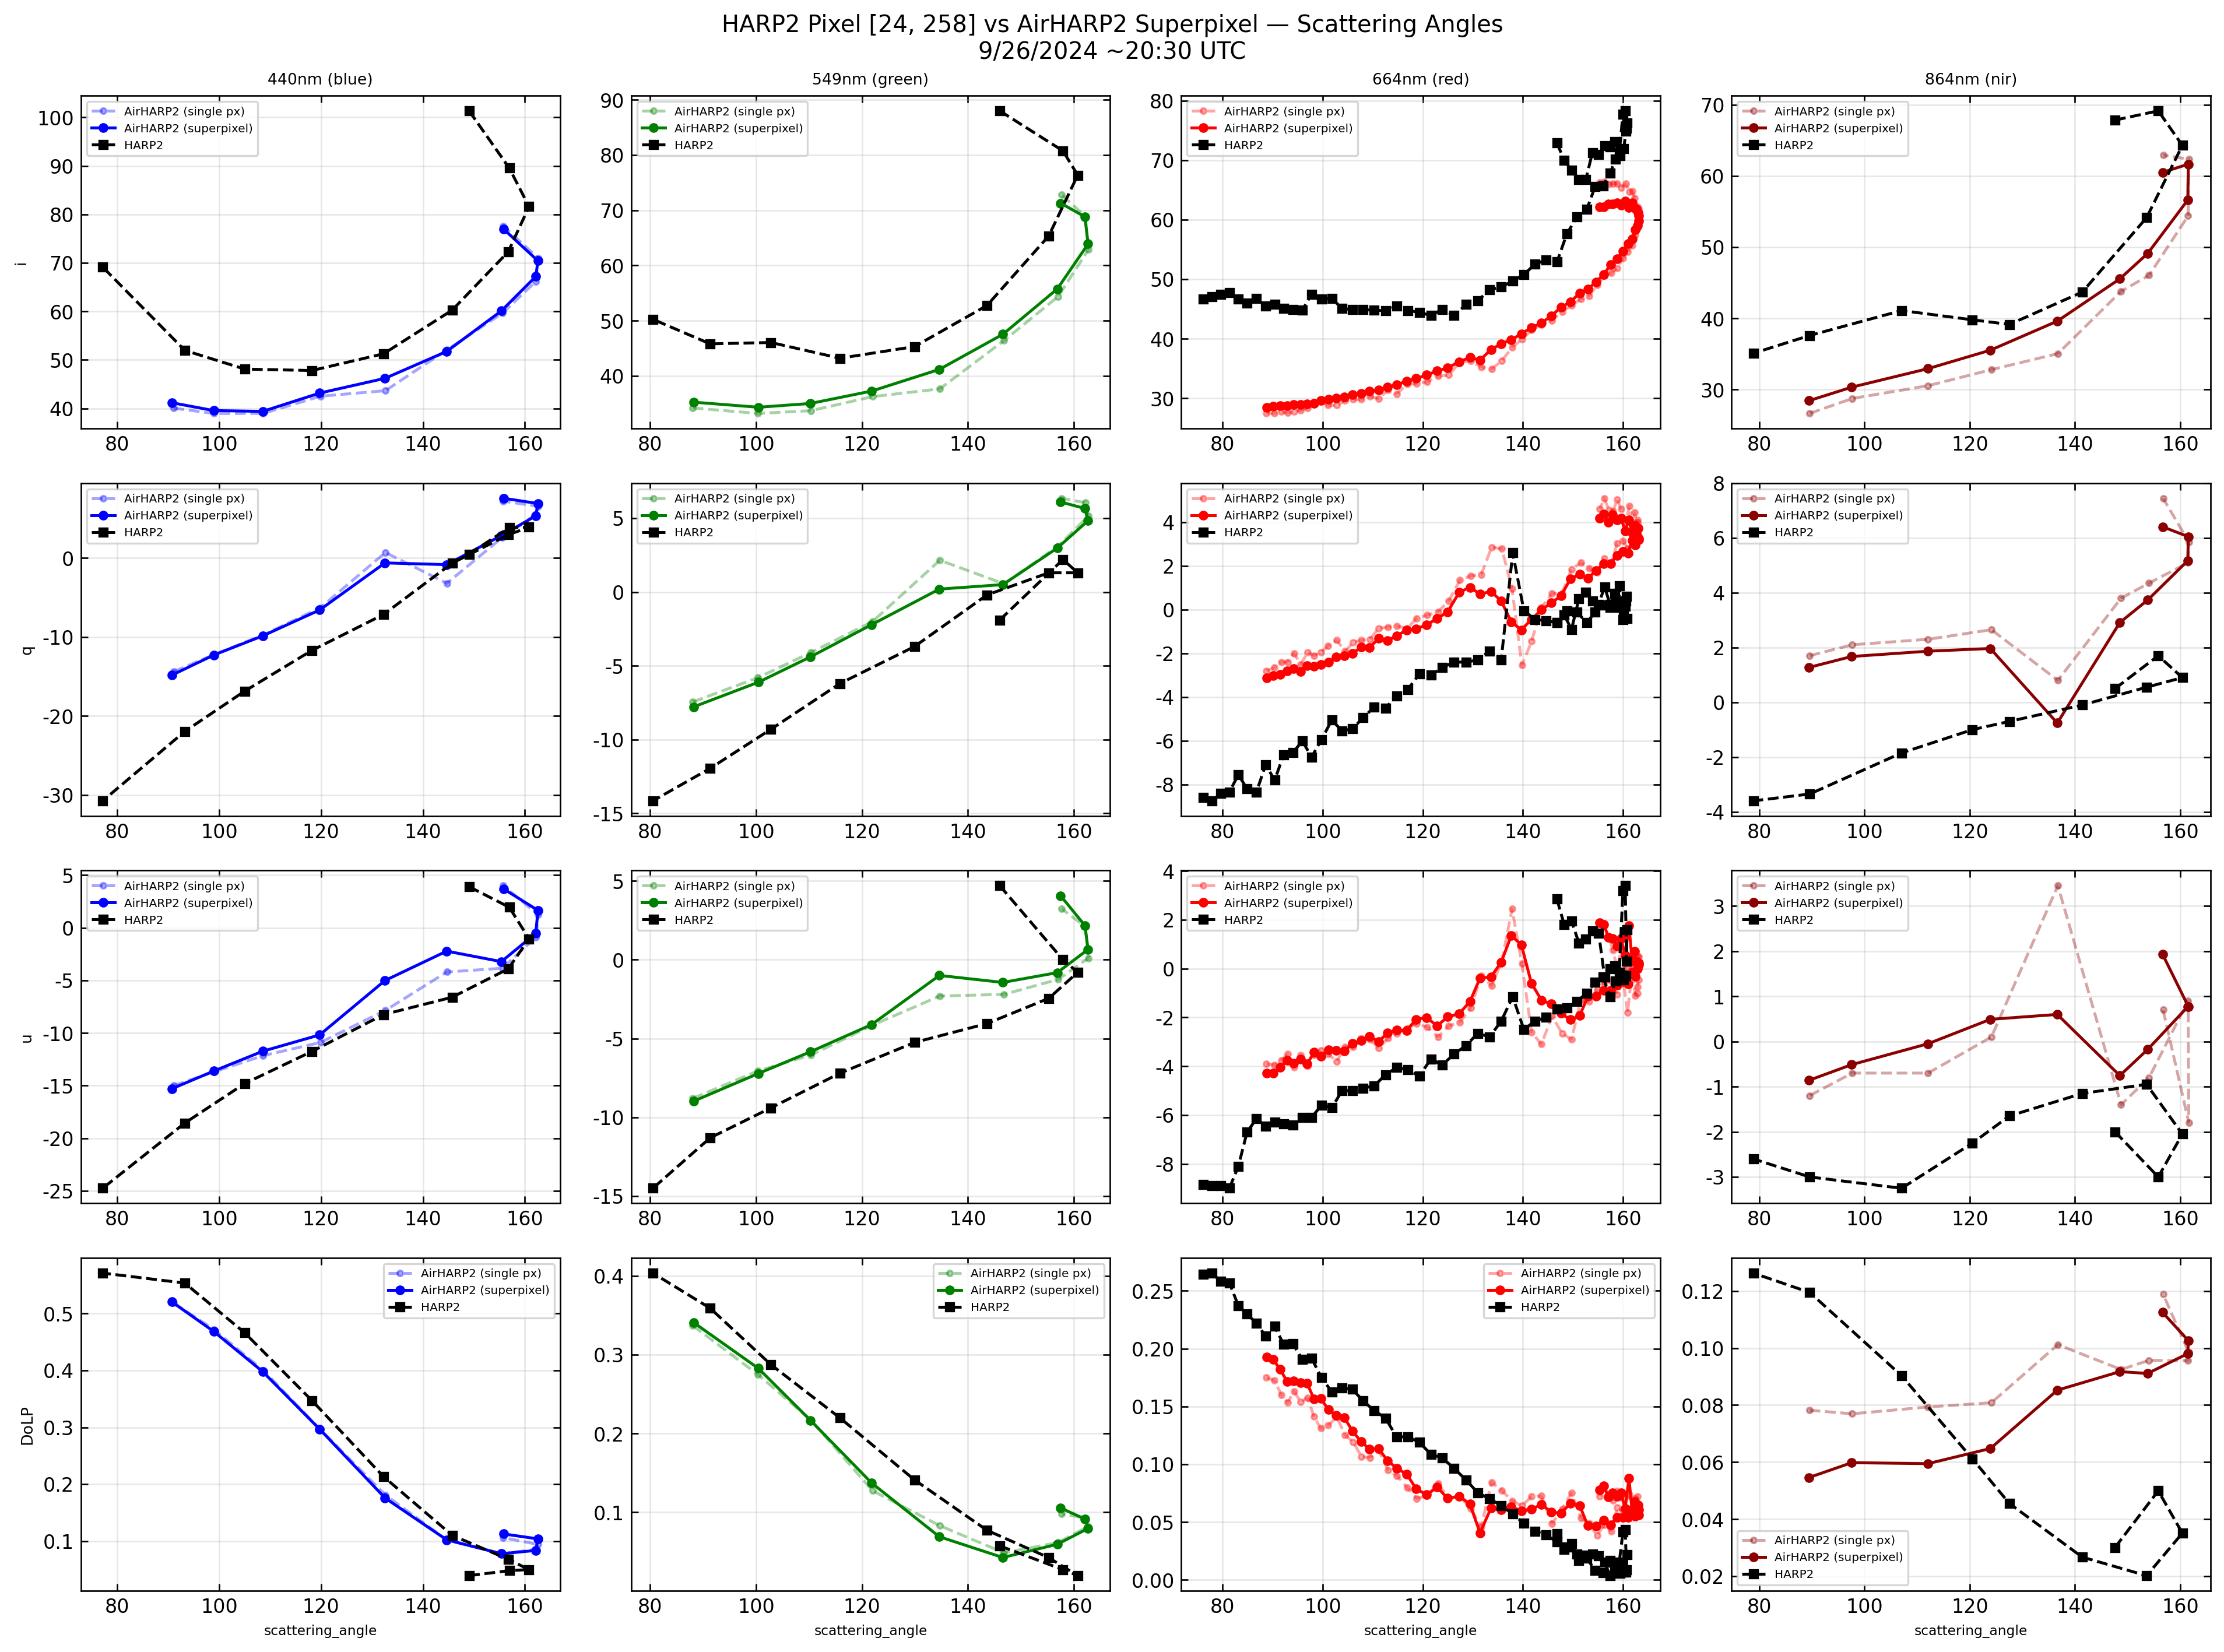

In [ ]:
ah2_vars_single_raw = {'i': ah2_i_pix, 'q': ah2_q_pix, 'u': ah2_u_pix, 'DoLP': ah2_dp}
ah2_vars_super_raw  = {'i': ah2_i_super, 'q': ah2_q_super, 'u': ah2_u_super, 'DoLP': ah2_dp_super}
h2_var_keys_raw     = ['i', 'q', 'u', 'dolp']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for row, (var_label, h2_key) in enumerate(zip(ah2_vars_single_raw.keys(), h2_var_keys_raw)):
    for col, (ah2_band, h2_band) in enumerate(zip(ah2_band_order, h2_band_order)):
        ax, idx = axes[row, col], bands[ah2_band]
        ax.plot(ah2_scat_pixel[idx], ah2_vars_single_raw[var_label][idx], 'o--', color=colors[ah2_band], alpha=0.35, markersize=3, label='AirHARP2 (single px)')
        ax.plot(ah2_scat_super[idx], ah2_vars_super_raw[var_label][idx], 'o-', color=colors[ah2_band], markersize=4, label='AirHARP2 (superpixel)')
        ax.plot(harp2_band_data[h2_band]['scattering_angle'], harp2_band_data[h2_band][h2_key], 's--', color='black', markersize=4, label='HARP2')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=6)
        if row == 0: ax.set_title(ah2_band, fontsize=8)
        if col == 0: ax.set_ylabel(var_label, fontsize=8)
        if row == 3: ax.set_xlabel('scattering_angle', fontsize=7)
fig.suptitle(f"HARP2 Pixel {h2_pixel} vs AirHARP2 Superpixel — Scattering Angles\n9/26/2024 ~20:30 UTC")
plt.tight_layout()
plt.show()

In [ ]:
def compare_curves(ah2_nominal, ah2_vals, h2_nominal, h2_vals, label=""):
    """Match by nearest nominal angle, then compute RMSE (relative), Spearman."""
    matched_ah2, matched_h2 = [], []
    for k, nom_val in enumerate(ah2_nominal):
        j = np.argmin(np.abs(h2_nominal - nom_val))
        matched_ah2.append(ah2_vals[k])
        matched_h2.append(h2_vals[j])
    matched_ah2 = np.array(matched_ah2)
    matched_h2  = np.array(matched_h2)

    diff = matched_h2 - matched_ah2
    rmse = np.sqrt(np.mean(diff**2))
    rel_rmse = rmse / np.mean(np.abs(matched_h2)) * 100  
    spearman_corr, _ = spearmanr(matched_ah2, matched_h2)      

    print(f"{label}: "f"rel.RMSE={rel_rmse:.1f}%   Spearman={spearman_corr:.3f}")
    return {'rel_rmse': rel_rmse, 'spearman': spearman_corr}

In [ ]:
print("=== View Angles (Reflectance) — Superpixel vs HARP2 ===")
results_view_super = {}
for band, h2_band in zip(ah2_band_order, h2_band_order):
    idx = bands[band]
    ah2_nominal = ah2_view_angles[idx]
    h2_nominal  = harp2_band_data[h2_band]['view_angles']

    for var_label, ah2_arr, h2_key in [('R_i', ah2_ri_super, 'ri'), ('R_q', ah2_rq_super, 'rq'),
                                         ('R_u', ah2_ru_super, 'ru'), ('DoLP', ah2_dp_super, 'dolp')]:
        key = f"{band} - {var_label}"
        results_view_super[key] = compare_curves(ah2_nominal, ah2_arr[idx],
                                                   h2_nominal, harp2_band_data[h2_band][h2_key],
                                                   label=key)
        
print("\n=== Scattering Angles (Raw radiance) — Superpixel vs HARP2 ===")
results_scat_super = {}
for band, h2_band in zip(ah2_band_order, h2_band_order):
    idx = bands[band]
    ah2_scat_x = ah2_scat_super[idx]                            # superpixel-averaged scattering angle
    h2_scat_x  = harp2_band_data[h2_band]['scattering_angle']

    for var_label, ah2_arr, h2_key in [('i', ah2_i_super, 'i'), ('q', ah2_q_super, 'q'),
                                         ('u', ah2_u_super, 'u'), ('DoLP', ah2_dp_super, 'dolp')]:
        key = f"{band} - {var_label}"
        results_scat_super[key] = compare_curves(ah2_scat_x, ah2_arr[idx],
                                                   h2_scat_x, harp2_band_data[h2_band][h2_key],
                                                   label=key)

=== View Angles (Reflectance) — Superpixel vs HARP2 ===
440nm (blue) - R_i: RMSE=0.0355 rel.RMSE=23.0%  Pearson=0.923  Spearman=0.830
440nm (blue) - R_q: RMSE=0.0167 rel.RMSE=72.3%  Pearson=0.958  Spearman=0.903
440nm (blue) - R_u: RMSE=0.0091 rel.RMSE=41.3%  Pearson=0.978  Spearman=0.988
440nm (blue) - DoLP: RMSE=0.0531 rel.RMSE=21.5%  Pearson=0.989  Spearman=0.794
549nm (green) - R_i: RMSE=0.0248 rel.RMSE=18.4%  Pearson=0.973  Spearman=0.818
549nm (green) - R_q: RMSE=0.0107 rel.RMSE=90.2%  Pearson=0.934  Spearman=0.867
549nm (green) - R_u: RMSE=0.0073 rel.RMSE=54.1%  Pearson=0.988  Spearman=0.988
549nm (green) - DoLP: RMSE=0.0618 rel.RMSE=37.8%  Pearson=0.932  Spearman=0.709
664nm (red) - R_i: RMSE=0.0366 rel.RMSE=23.3%  Pearson=0.950  Spearman=0.797
664nm (red) - R_q: RMSE=0.0098 rel.RMSE=125.2%  Pearson=0.874  Spearman=0.847
664nm (red) - R_u: RMSE=0.0060 rel.RMSE=66.2%  Pearson=0.912  Spearman=0.910
664nm (red) - DoLP: RMSE=0.0456 rel.RMSE=49.7%  Pearson=0.927  Spearman=0.810
864n

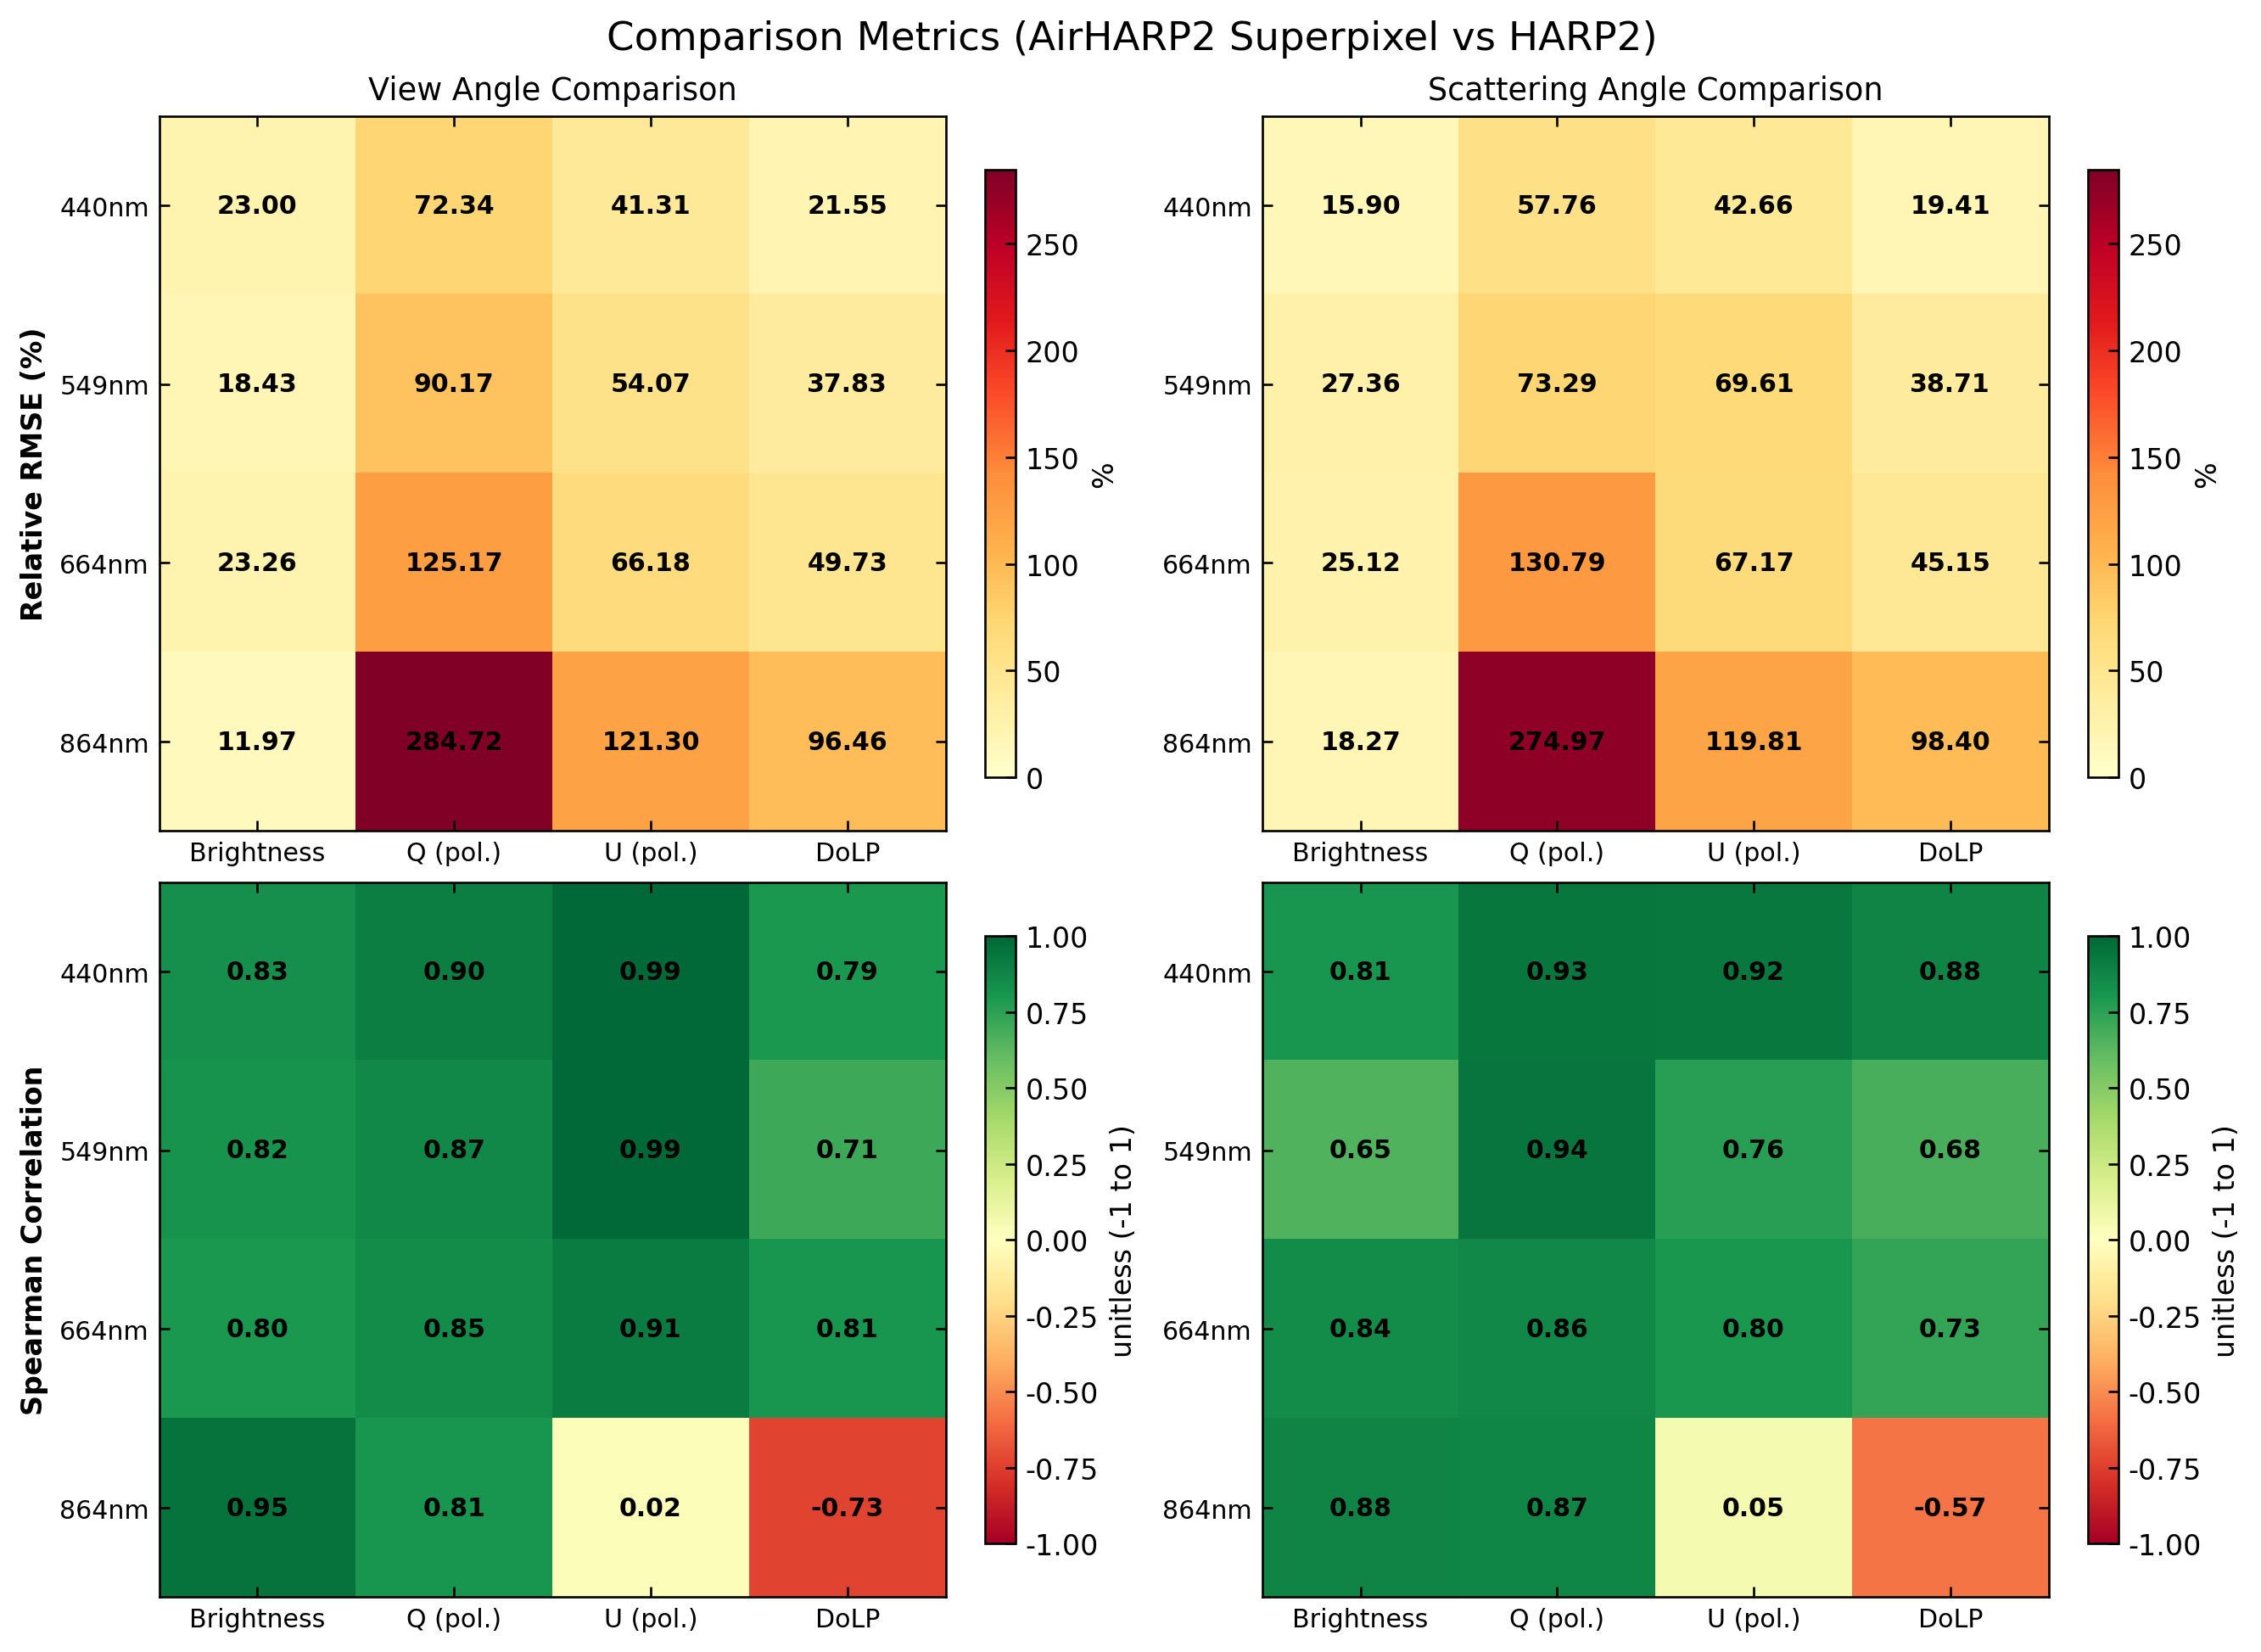

In [18]:
def plot_relrmse_spearman_summary(results_view, results_scat, band_order,
                                   var_keys_view, var_keys_scat, var_display_labels):
    metrics = [
        ('rel_rmse', 'YlOrRd', 0, None, 'Relative RMSE (%)'),
        ('spearman', 'RdYlGn', -1, 1,   'Spearman Correlation'),
    ]
    units = {
        'rel_rmse': {'view': '%', 'scat': '%'},
        'spearman': {'view': 'unitless (-1 to 1)', 'scat': 'unitless (-1 to 1)'},
    }
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
    for row, (metric, cmap, vmin, vmax_fixed, metric_title) in enumerate(metrics):
        if vmax_fixed is None:
            all_vals = []
            for results, var_keys in [(results_view, var_keys_view), (results_scat, var_keys_scat)]:
                for band in band_order:
                    for var in var_keys:
                        key = f"{band} - {var}"
                        if key in results:
                            all_vals.append(results[key][metric])
            vmax = np.nanmax(all_vals)
        else:
            vmax = vmax_fixed
        for col, (results, var_keys, subtitle, side) in enumerate(zip(
            [results_view, results_scat], [var_keys_view, var_keys_scat],
            ['View Angle Comparison', 'Scattering Angle Comparison'], ['view', 'scat']
        )):
            ax = axes[row, col]
            grid = np.full((len(band_order), len(var_keys)), np.nan)
            for i, band in enumerate(band_order):
                for j, var in enumerate(var_keys):
                    key = f"{band} - {var}"
                    if key in results:
                        grid[i, j] = results[key][metric]
            im = ax.imshow(grid, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
            ax.set_xticks(range(len(var_keys))); ax.set_xticklabels(var_display_labels, fontsize=9)
            ax.set_yticks(range(len(band_order)))
            ax.set_yticklabels([b.split(' ')[0] for b in band_order], fontsize=9)
            for i in range(len(band_order)):
                for j in range(len(var_keys)):
                    val = grid[i, j]
                    if not np.isnan(val):
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=9, fontweight='bold')
            if row == 0:
                ax.set_title(subtitle, fontsize=11)
            if col == 0:
                ax.set_ylabel(metric_title, fontsize=10, fontweight='bold')
            fig.colorbar(im, ax=ax, shrink=0.85, label=units[metric][side])
    fig.suptitle('Comparison Metrics (AirHARP2 Superpixel vs HARP2)', fontsize=14)
    plt.show()

var_keys_view = ['R_i', 'R_q', 'R_u', 'DoLP']
var_keys_scat = ['i', 'q', 'u', 'DoLP']
var_display_labels = ['Brightness', 'Q (pol.)', 'U (pol.)', 'DoLP']
plot_relrmse_spearman_summary(results_view_super, results_scat_super, ah2_band_order,
                               var_keys_view, var_keys_scat, var_display_labels)